# 02 — A hybrid neural density model with a linear scale nuisance

We now build the **good fitted model**, before deliberately introducing misspecification in notebook 03. There is no event selection. The five reconstructed observables $x=(x_1,\ldots,x_5)$ enter the density networks; physical parameters enter the likelihood later.

The reference design is the same as Exercise 5: an equally weighted nominal signal/background mixture, learned by a normalized flow $p_{\mathrm{ref}}(x)$. Its 50:50 training composition is a numerical choice. The experiment still has $S=100$ and $B=10\,000$ at $\mu=1$.

We train nominal process/reference ratios and up/down process/nominal ratios, normalize the resulting six complete anchors, and use **linear interpolation of normalized densities**. This gives shape-only nuisance variations without a parameter-dependent normalization integral.

Run notebook 01 first. The defaults preserve the previous training sizes and architectures. Full training requires a GPU and substantial memory; this notebook does not claim good training until the held-out diagnostics below have been inspected.

## Setup and shared run directory

Run this cell first. Use the same `RUN_NAME` in all five notebooks. Colab can keep the run on Drive; locally, open Jupyter in this directory. Use a fresh kernel when switching from the older exercises. Training and samples remain in the run directory.


In [1]:
# Run this cell first in each notebook. All five notebooks share RUN_NAME.
import os
import sys
import subprocess
from pathlib import Path

RUN_NAME = "default"  # Use a new name when changing the model or training setup.
USE_DRIVE = True
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO = Path("/content/nsbi_calibration_toolkit")
    BRANCH = "ml4hep_school_tutorial"
    if not (REPO / ".git").exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH,
            "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git", str(REPO),
        ], check=True, env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"})
        subprocess.run([
            "git", "-C", str(REPO), "sparse-checkout", "set", "src",
            "workshops/ml4hep_tifr_colab/calibration",
        ], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only", "origin", BRANCH], check=True)
    SOURCE = REPO / "workshops/ml4hep_tifr_colab/calibration"
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", "-r",
        str(SOURCE / "requirements.txt"),
    ], check=True)
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        RUN_BASE = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs")
    else:
        RUN_BASE = Path("/content/calibration_runs")
else:
    # Open the notebook with calibration/ as its working directory.
    SOURCE = Path.cwd().resolve()
    REPO = SOURCE.parents[2]
    RUN_BASE = SOURCE / "runs"

sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(SOURCE))
os.chdir(SOURCE)
RUN = Path(os.environ.get("CALIBRATION_RUN", RUN_BASE / RUN_NAME)).resolve()
RUN.mkdir(parents=True, exist_ok=True)
print("Source:", SOURCE)
print("Run:", RUN)
print("Use a fresh kernel when switching between the old exercises and calibration.")


Mounted at /content/drive
Source: /content/nsbi_calibration_toolkit/workshops/ml4hep_tifr_colab/calibration
Run: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default
Use a fresh kernel when switching between the old exercises and calibration.


In [2]:
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from model import FEATURES, load_config, morph, nll, fit, asimov_weights
from sampling import read_sample
from flow_reference import train_reference, MODEL_DEFAULTS, TRAIN_DEFAULTS
from utils import (HybridModel, RatioEnsemble, train_ratio, save_hybrid,
                   plot_ratio_diagnostics, plot_shape_closure, RATIO_DEFAULTS)

config = load_config(RUN)
SEED = config['seed'] + 100
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
HYBRID = RUN / 'hybrid'
PLOTS = HYBRID / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)
print('Device:', DEVICE)
print('Sample configuration:', config['samples'])

Device: cuda
Sample configuration: {'flow_train_per_process': 500000, 'nominal_ratio_per_class': 5000000, 'evaluation_per_process': 250000, 'variation_ratio_per_class': 1000000}


## 1. Fix the sample budgets and the model definitions

| Stage | Input sample size | Network |
|---|---:|---|
| Reference flow | 500,000 nominal events per process | 10 spline coupling layers, 16 bins, tail bound 5; 4-block networks of width 1024 |
| Nominal signal/reference and background/reference ratios | 5,000,000 events per class | Four independently initialized members, 4 hidden layers of width 1024 |
| Each up/down to nominal deformation ratio | 1,000,000 events per class | One network, 4 hidden layers of width 1024 |
| Anchor normalization | 5,000,000 fresh reference-flow events | No training |
| External diagnostics | Up to 250,000 independent events per process/anchor | No training or tuning |

The first three sizes come from notebook 01's configuration, so a reduced run remains internally consistent. The flow and nominal ratio training partitions are disjoint. Scale variations share latent events with their nominal partners; the final diagnostics use an entirely separate row block. For the deformation classifiers we use the first 1,000,000 varied rows and the last 1,000,000 nominal ratio-training rows, so paired latent events do not straddle their internal splits at the default sizes. The final, disjoint diagnostic block remains the decisive validation.

`REUSE=True` reloads a stage already trained in this run. Use a **new run name** when changing samples, architecture, or training settings; this keeps the next notebooks tied to one concrete density model.

In [3]:
REUSE = True
N_REFERENCE_INTEGRATION = 5_000_000
N_DIAGNOSTIC_REFERENCE = 250_000
NOMINAL_ENSEMBLE = 4
FLOW_MODEL = dict(MODEL_DEFAULTS)
FLOW_TRAINING = dict(TRAIN_DEFAULTS)
RATIO_TRAINING = dict(RATIO_DEFAULTS)

settings = dict(reference_integration=N_REFERENCE_INTEGRATION,
                diagnostic_reference=N_DIAGNOSTIC_REFERENCE,
                nominal_ensemble=NOMINAL_ENSEMBLE,
                flow_model=FLOW_MODEL, flow_training=FLOW_TRAINING,
                ratio_training=RATIO_TRAINING)
(HYBRID / 'training_settings.json').write_text(json.dumps(settings, indent=2))

854

## 2. Learn a reusable reference density

Train the flow by maximum likelihood on the balanced nominal sample:

$$\mathcal L_{\mathrm{flow}}=-\frac{1}{M}\sum_{j=1}^{M}\log p_{\mathrm{ref},\phi}(x_j).$$

The standardization is fitted on the flow's optimization split, and its Jacobian is included in `log_prob`. The flow's exact normalization comes from its invertible construction. Agreement with the desired mixture must still be checked on independent data.

flow epoch 01: train=6.57022, val=6.48552
flow epoch 02: train=6.47818, val=6.47148
flow epoch 03: train=6.46736, val=6.46480
flow epoch 04: train=6.46246, val=6.46464
flow epoch 05: train=6.45992, val=6.46024
flow epoch 06: train=6.45760, val=6.45968
flow epoch 07: train=6.45648, val=6.46064
flow epoch 08: train=6.45559, val=6.45697
flow epoch 09: train=6.45410, val=6.45823
flow epoch 10: train=6.45364, val=6.45810
flow epoch 11: train=6.45227, val=6.45615
flow epoch 12: train=6.45195, val=6.45727
flow epoch 13: train=6.45115, val=6.45711
flow epoch 14: train=6.45076, val=6.45602
flow epoch 15: train=6.43692, val=6.44461
flow epoch 16: train=6.43541, val=6.44434
flow epoch 17: train=6.43511, val=6.44457
flow epoch 18: train=6.43485, val=6.44465
flow epoch 19: train=6.43152, val=6.44239
flow epoch 20: train=6.43107, val=6.44238
flow epoch 21: train=6.43100, val=6.44246
flow epoch 22: train=6.43090, val=6.44260
flow epoch 23: train=6.43008, val=6.44227
flow epoch 24: train=6.42999, val=

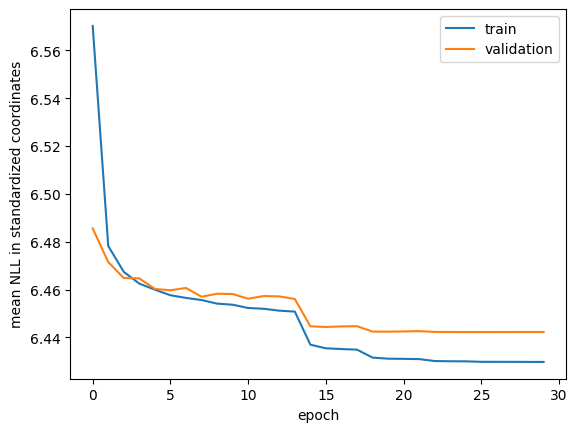

In [4]:
flow_training_x = np.concatenate([
    read_sample(RUN, process, partition='flow_train')
    for process in ['signal', 'background']])
reference_flow = train_reference(
    flow_training_x, HYBRID / 'reference.pt', model_config=FLOW_MODEL,
    training_config=FLOW_TRAINING, device=DEVICE, seed=SEED, reuse=REUSE)
del flow_training_x
gc.collect()

saved_flow = torch.load(HYBRID / 'reference.pt', map_location='cpu', weights_only=False)
history = np.asarray(saved_flow['history'])
plt.plot(history[:, 0], label='train')
plt.plot(history[:, 1], label='validation')
plt.xlabel('epoch'); plt.ylabel('mean NLL in standardized coordinates'); plt.legend()
plt.savefig(PLOTS / 'flow_loss.png', bbox_inches='tight')
plt.show()
del saved_flow

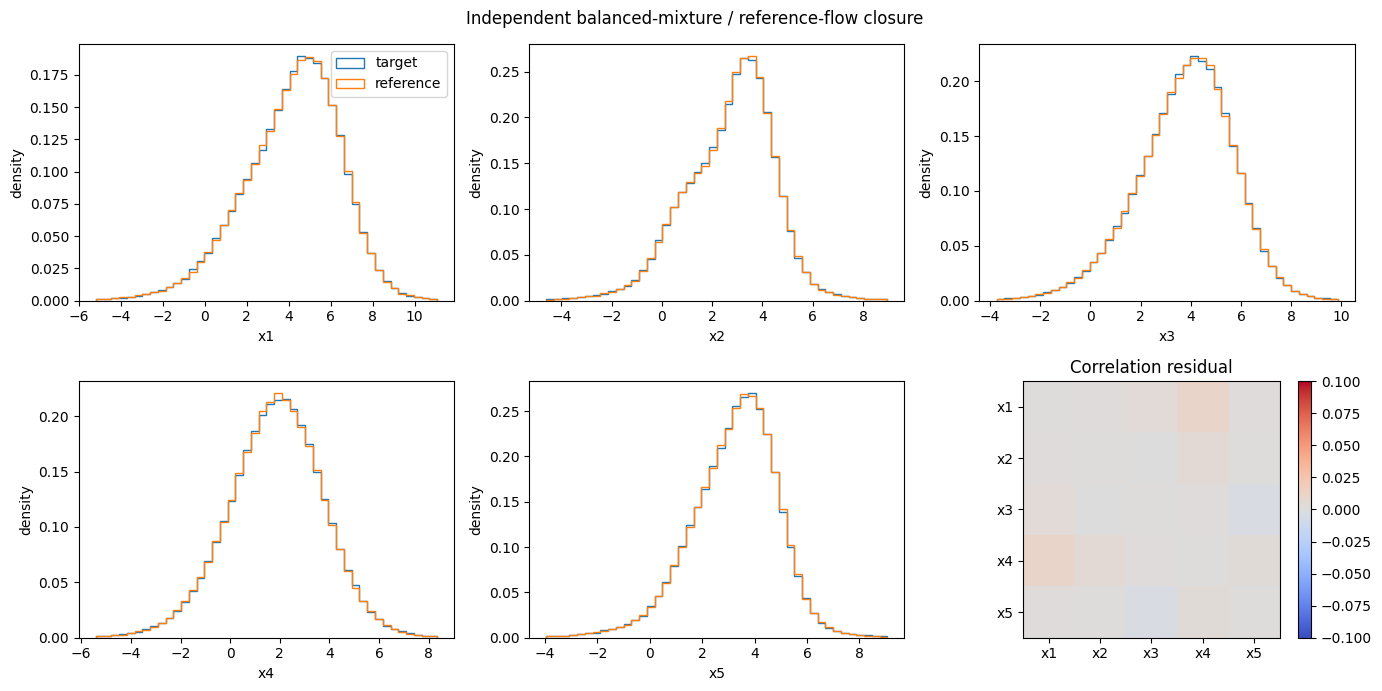

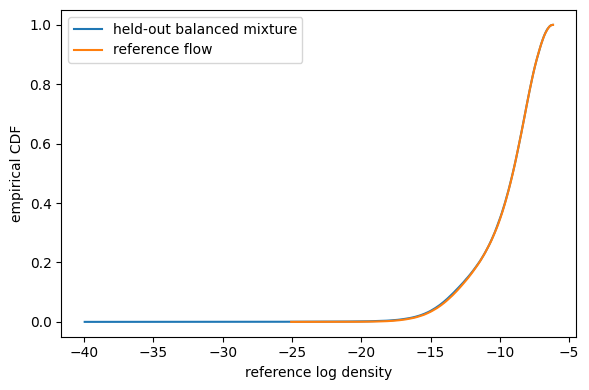

In [5]:
flow_target = np.concatenate([
    read_sample(RUN, process, partition='eval', n=min(125_000, config['samples']['evaluation_per_process']))
    for process in ['signal', 'background']])
flow_diagnostic_x = reference_flow.sample(N_DIAGNOSTIC_REFERENCE, SEED + 1)
fig = plot_shape_closure(flow_target, flow_diagnostic_x,
                         title='Independent balanced-mixture / reference-flow closure')
fig.savefig(PLOTS / 'flow_shape_closure.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for x, label in [(flow_target, 'held-out balanced mixture'),
                 (flow_diagnostic_x, 'reference flow')]:
    logp = np.sort(reference_flow.log_prob(x))
    ax.plot(logp, np.arange(1, len(logp) + 1) / len(logp), label=label)
ax.set(xlabel='reference log density', ylabel='empirical CDF')
ax.legend(); fig.tight_layout()
fig.savefig(PLOTS / 'flow_log_density_cdf.png')
plt.show()
del flow_target

## 3. Train the nominal process/reference ratios

A classifier with equally normalized class weights minimizes binary cross entropy. Its optimal logit is

$$\ell_c(x)=\log\frac{p_c(x)}{p_{\mathrm{ref}}(x)},\qquad r_c(x)=\exp\ell_c(x).$$

We use the existing `nsbi_common_utils` trainer, with its logit-output option. This is the same classification objective, and avoids converting a numerically saturated sigmoid back into a ratio. `utils.py` returns the arithmetic mean of the four member **ratios**, as in the earlier exercises.

The flow-generated denominator below is used only for ratio training. Neither the normalization bank nor the independent diagnostic reference sample is taken from it. The external reliability plot tests the actual ensemble prediction; the reweighting plots test whether denominator events weighted by the predicted ratio reproduce the target.

2026-09-29 19:34:51 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal/num_events_random_state_train_holdout_split0.npy
2026-09-29 19:34:57 | INFO | Training Logs | Sum of weights of class 0: 0.7500000000000044
INFO:Tra

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693375 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.632120 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.636639 | val_loss = 0.632385 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.632486 | val_loss = 0.632222 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.632248 | val_loss = 0.631913 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.632127 | val_loss = 0.631886 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.632028 | val_loss = 0.631641 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.631941 | val_loss = 0.631414 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.631853 | val_loss = 0.631663 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.631795 | val_loss = 0.631597 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.631733 | val_loss = 0.631423 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.631684 | val_loss = 0.631085 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.631195 | val_loss = 0.631054 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.63

...

2026-09-30 01:42:03 | INFO | Training Logs | Finished Training
INFO:Training Logs:Finished Training
/content/nsbi_calibration_toolkit/src/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 01:42:03.800000 443 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


<Figure size 800x600 with 0 Axes>

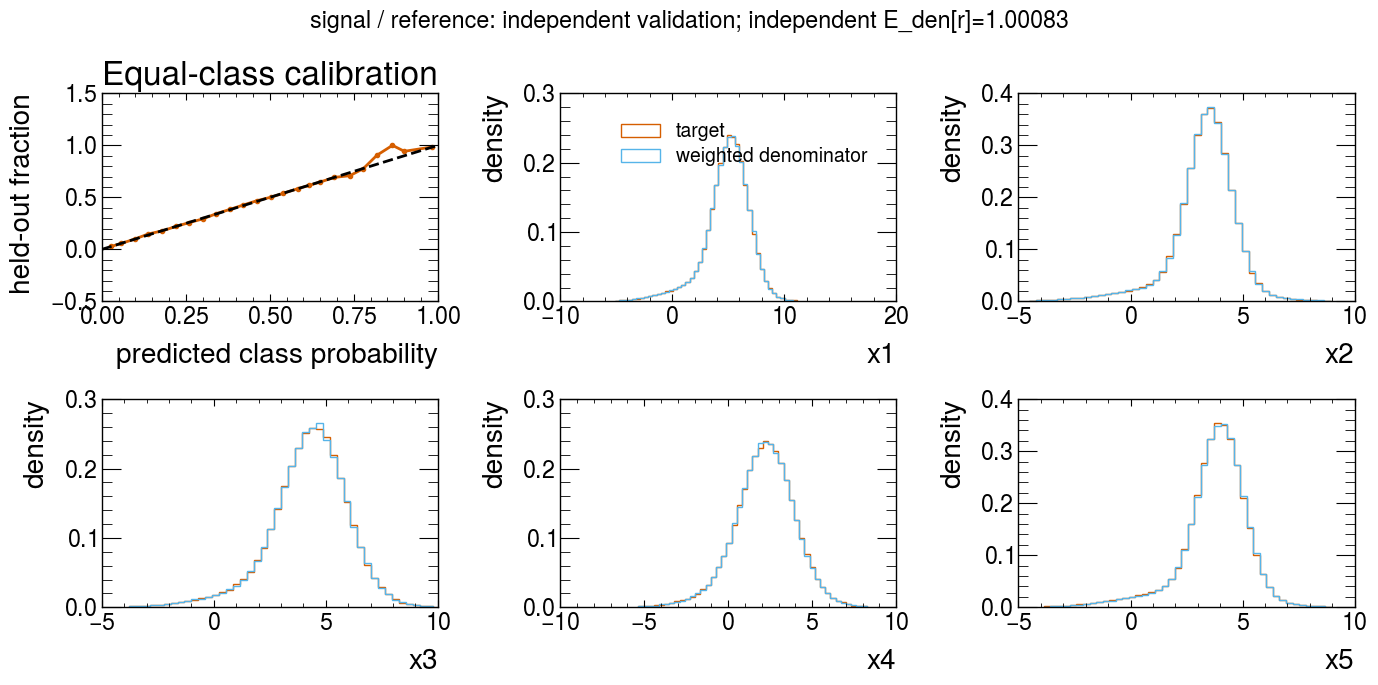

2026-09-30 02:09:31 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background/num_events_random_state_train_holdout_split0.npy
2026-09-30 02:09:36 | INFO | Training Logs | Sum of weights of class 0: 0.7

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693030 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.652099 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.658934 | val_loss = 0.651592 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.651825 | val_loss = 0.651897 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.651544 | val_loss = 0.651320 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.651417 | val_loss = 0.651682 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.651307 | val_loss = 0.651438 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.651203 | val_loss = 0.651289 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.651105 | val_loss = 0.651408 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.651037 | val_loss = 0.651298 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.650974 | val_loss = 0.651241 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.650936 | val_loss = 0.650830 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.650526 | val_loss = 0.650800 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.65

...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


2026-09-30 08:16:09 | WARNING | Training Logs | background training data has max score = 1, which may indicate numerical instability!
2026-09-30 08:16:09 | WARNING | Training Logs | background holdout data has max score = 1, which may indicate numerical instability!


<Figure size 800x600 with 0 Axes>

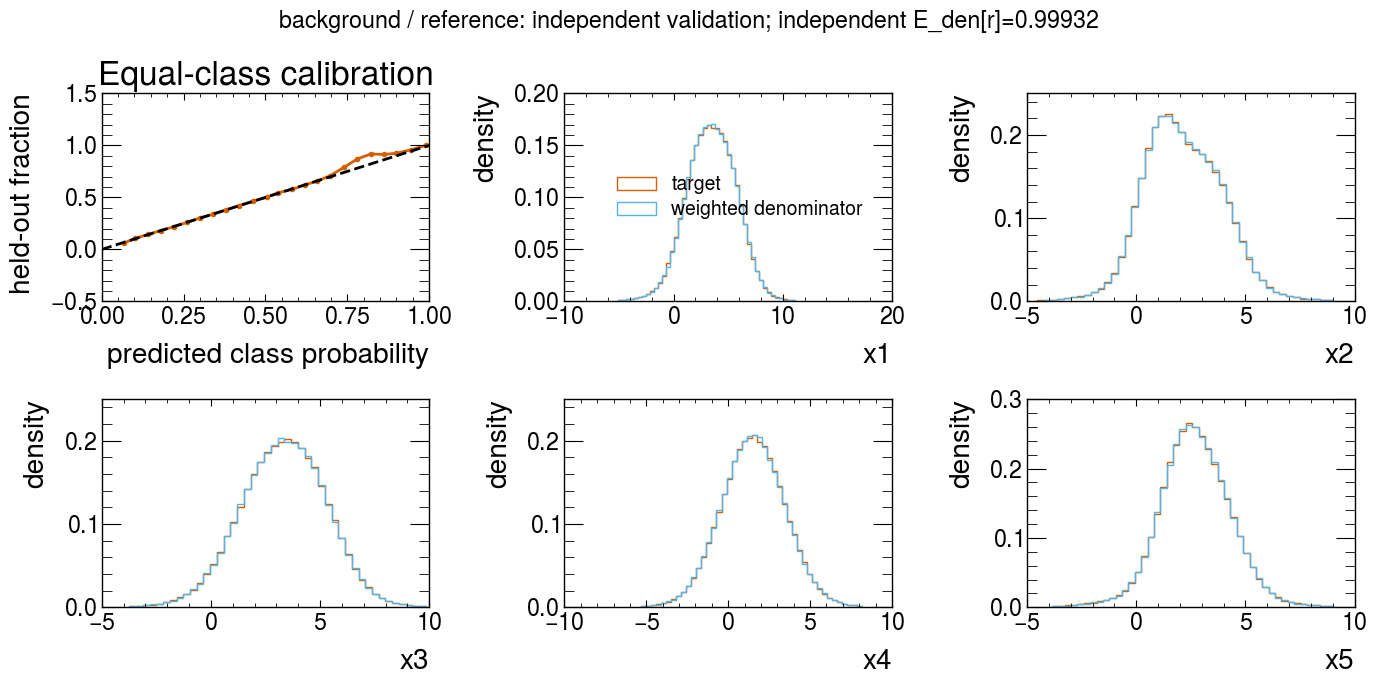

In [6]:
n_ratio = config['samples']['nominal_ratio_per_class']
reference_ratio_training = reference_flow.sample(n_ratio, SEED + 2)
ratio_models = {}
for i, process in enumerate(['signal', 'background']):
    target = read_sample(RUN, process, partition='ratio_train', n=n_ratio)
    ratio_models[process] = train_ratio(
        target, reference_ratio_training, HYBRID / 'ratios' / process,
        members=NOMINAL_ENSEMBLE, seed=SEED + 100 + 10 * i,
        settings=RATIO_TRAINING, reuse=REUSE)
    heldout = read_sample(RUN, process, partition='eval')
    fig = plot_ratio_diagnostics(ratio_models[process], heldout, flow_diagnostic_x,
                                 title=f'{process} / reference: independent validation')
    fig.savefig(PLOTS / f'ratio_{process}.png', bbox_inches='tight')
    plt.show()
    del target, heldout
    gc.collect()
del reference_ratio_training

## 4. Learn the scale-deformation ratios

For each process we train two more classifiers,

$$d_c^\pm(x)=\frac{p_c^{\pm}(x)}{p_c^0(x)}.$$

Their inputs are again the five reconstructed variables; neither $\mu$ nor $\alpha$ enters these fixed-anchor classifiers. The complete raw reference-relative anchors are

$$\widetilde R_c^0=r_c,\qquad \widetilde R_c^- = r_c d_c^-,\qquad \widetilde R_c^+=r_c d_c^+.$$

The deformation ratios are not interpolated in log space. We first construct and normalize these **complete process/reference anchors**, and only then interpolate. We also validate the complete products below: separately good nominal and deformation plots do not by themselves establish good hNDE closure.

2026-09-30 08:18:56 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_down/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_down/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_down/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_down/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_down/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_down/num_events_random_state_train_holdout_split0.npy
2026-09-30 08:18:57 | INFO | Training Logs | Sum of weights of class 

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693188 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.638050 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.648203 | val_loss = 0.637371 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.639009 | val_loss = 0.637256 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.638291 | val_loss = 0.637377 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.638081 | val_loss = 0.636986 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.637858 | val_loss = 0.637213 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.637745 | val_loss = 0.637061 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.637545 | val_loss = 0.636921 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.637489 | val_loss = 0.636950 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.637425 | val_loss = 0.636777 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.637410 | val_loss = 0.636557 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.636901 | val_loss = 0.636523 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.63

2026-09-30 08:27:13 | INFO | Training Logs | Finished Training
INFO:Training Logs:Finished Training
/content/nsbi_calibration_toolkit/src/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 08:27:13.924000 443 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


<Figure size 800x600 with 0 Axes>

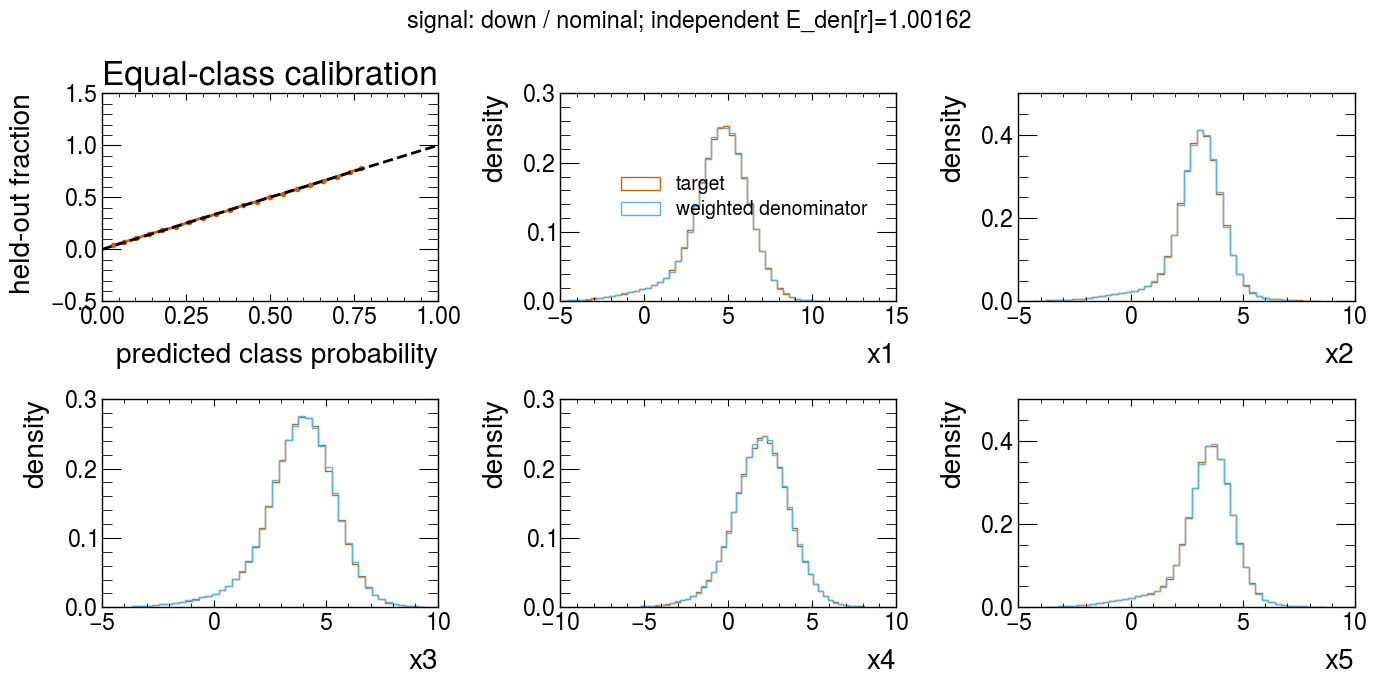

2026-09-30 08:32:46 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_up/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_up/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_up/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_up/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_up/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/signal_up/num_events_random_state_train_holdout_split0.npy
2026-09-30 08:32:47 | INFO | Training Logs | Sum of weights of class 0: 0.7499999

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693258 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.653277 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.660345 | val_loss = 0.645120 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.647391 | val_loss = 0.645626 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.645323 | val_loss = 0.645262 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.645140 | val_loss = 0.645054 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.645114 | val_loss = 0.645039 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.644925 | val_loss = 0.645760 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.644860 | val_loss = 0.644972 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.644750 | val_loss = 0.644894 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.644698 | val_loss = 0.645548 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.644625 | val_loss = 0.644712 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.644189 | val_loss = 0.644677 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.64

2026-09-30 08:41:53 | INFO | Training Logs | Finished Training
INFO:Training Logs:Finished Training
/content/nsbi_calibration_toolkit/src/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 08:41:53.773000 443 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


<Figure size 800x600 with 0 Axes>

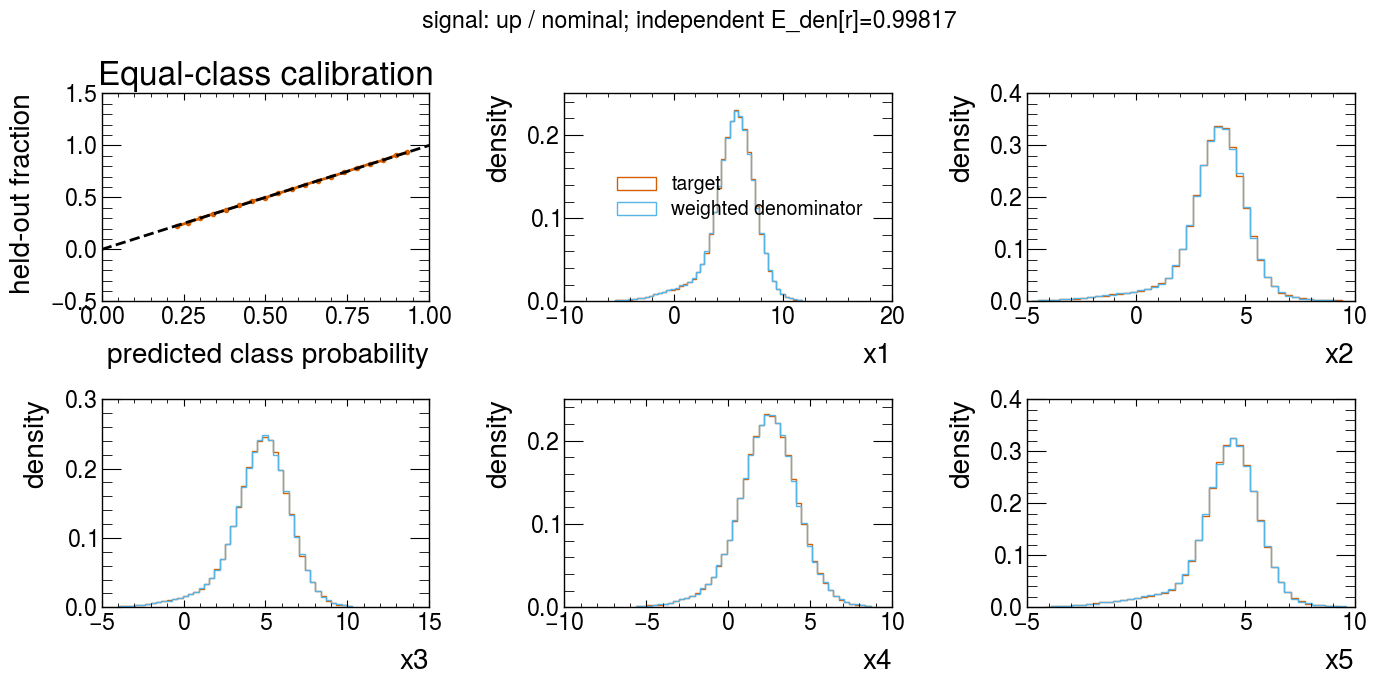

2026-09-30 08:47:29 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_down/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_down/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_down/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_down/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_down/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_down/num_events_random_state_train_holdout_split0.npy
2026-09-30 08:47:30 | INFO | Training Logs | 

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693141 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.671159 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.678163 | val_loss = 0.668352 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.670309 | val_loss = 0.668117 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.669069 | val_loss = 0.667732 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.668422 | val_loss = 0.668458 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.668118 | val_loss = 0.667660 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.668003 | val_loss = 0.667418 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.667943 | val_loss = 0.667909 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.667854 | val_loss = 0.667878 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.667824 | val_loss = 0.667959 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.667802 | val_loss = 0.667187 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.667323 | val_loss = 0.667145 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.66

2026-09-30 08:56:24 | INFO | Training Logs | Finished Training
INFO:Training Logs:Finished Training
/content/nsbi_calibration_toolkit/src/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 08:56:24.874000 443 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


<Figure size 800x600 with 0 Axes>

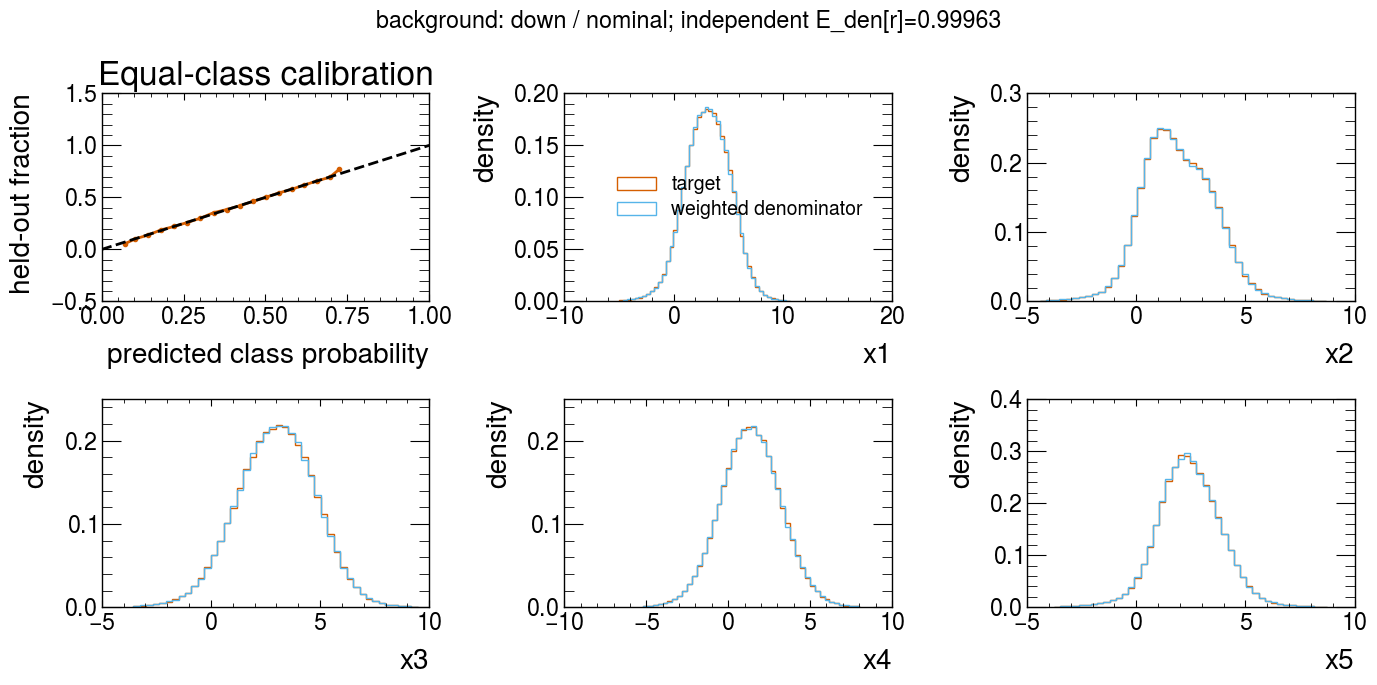

2026-09-30 09:02:01 | WARNING | Training Logs | load_trained_models=True but the following files were not found, retraining:
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_up/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_up/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_up/num_events_random_state_train_holdout_split0.npy
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_up/model_scaler0.bin
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_up/model0.onnx
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/default/hybrid/ratios/background_up/num_events_random_state_train_holdout_split0.npy
2026-09-30 09:02:01 | INFO | Training Logs | Sum of weigh

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693104 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.674588 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.681634 | val_loss = 0.671550 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.672851 | val_loss = 0.671558 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.671616 | val_loss = 0.671095 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.671190 | val_loss = 0.670060 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.670856 | val_loss = 0.670306 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.670722 | val_loss = 0.670839 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.670579 | val_loss = 0.669889 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.670480 | val_loss = 0.669937 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.670423 | val_loss = 0.670077 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.670339 | val_loss = 0.669670 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.669892 | val_loss = 0.669641 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.66

2026-09-30 09:14:01 | INFO | Training Logs | Finished Training
INFO:Training Logs:Finished Training
/content/nsbi_calibration_toolkit/src/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 09:14:01.069000 443 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


<Figure size 800x600 with 0 Axes>

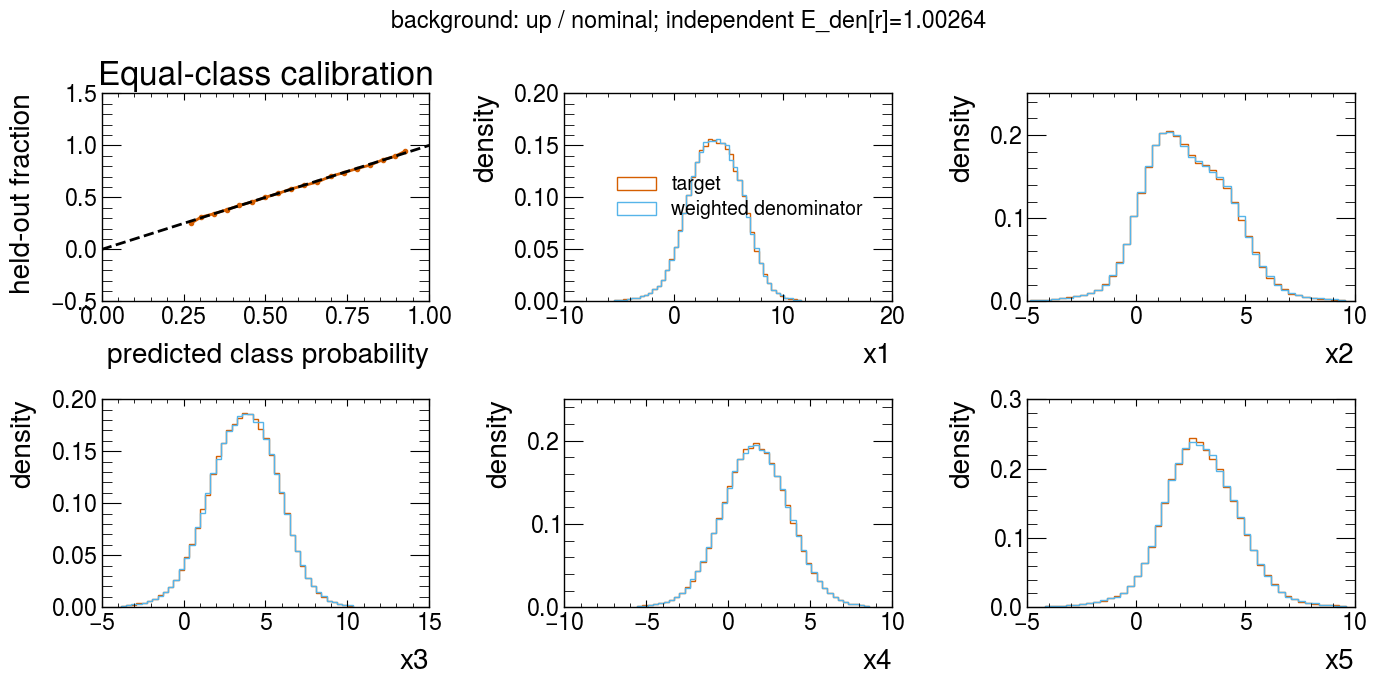

In [7]:
n_variation = config['samples']['variation_ratio_per_class']
for i, process in enumerate(['signal', 'background']):
    # Different latent rows from the varied numerator, whose first rows are used.
    nominal = read_sample(RUN, process, partition='ratio_train')[-n_variation:].copy()
    nominal_eval = read_sample(RUN, process, partition='eval')
    for j, direction in enumerate(['down', 'up']):
        name = f'{process}_{direction}'
        varied = read_sample(RUN, process, partition='ratio_train',
                             anchor=direction, n=n_variation)
        ratio_models[name] = train_ratio(
            varied, nominal, HYBRID / 'ratios' / name,
            members=1, seed=SEED + 200 + 10 * i + j,
            settings=RATIO_TRAINING, reuse=REUSE)
        varied_eval = read_sample(RUN, process, partition='eval', anchor=direction)
        fig = plot_ratio_diagnostics(ratio_models[name], varied_eval, nominal_eval,
                                     title=f'{process}: {direction} / nominal')
        fig.savefig(PLOTS / f'ratio_{name}.png', bbox_inches='tight')
        plt.show()
        del varied, varied_eval
        gc.collect()
    del nominal, nominal_eval

## 5. Normalize the complete anchors once

Draw a fresh integration bank $X_j\sim p_{\mathrm{ref}}$ and define

$$Z_c^k=\frac{1}{M}\sum_j\widetilde R_c^k(X_j),\qquad
R_c^k(x)=\frac{\widetilde R_c^k(x)}{Z_c^k},\quad k\in\{-,0,+\}.$$

The saved array is ordered `[process, anchor] = [signal/background, down/nominal/up]`. Each anchor has sample mean exactly one on this bank. This is **Monte Carlo normalization**, not exact normalization under the continuous flow: the independent closure table next estimates its residual integration error.

For $-1\leq\alpha\leq1$,

$$R_c(x;\alpha)=(1-|\alpha|)R_c^0(x)
 +\max(\alpha,0)R_c^+(x)+\max(-\alpha,0)R_c^-(x).$$

All coefficients are nonnegative and sum to one. Consequently the shapes stay positive and normalized on the integration bank for every allowed $\alpha$. Yields remain $\nu S$ and $B$. We restrict the fit range to $[-1,1]$; extrapolation could produce negative densities and is not part of this model.

In [8]:
if REUSE and (HYBRID / 'manifest.json').exists():
    hybrid = HybridModel.load(RUN, DEVICE)
else:
    hybrid = HybridModel(RUN, reference_flow, ratio_models)
    manifest = save_hybrid(hybrid, n_reference=N_REFERENCE_INTEGRATION, seed=SEED + 3)
    print('Saved hybrid model:', manifest['model_id'])

integration_anchors = hybrid.reference_anchors()
print('Raw anchor normalizations, rows S/B and columns down/nominal/up:')
print(hybrid.normalization)
print('Integration-bank normalized means:')
print(np.mean(integration_anchors, axis=0))
print('Model ID:', hybrid.model_id)

Saved hybrid model: 8ee9dfc132cf191f
Raw anchor normalizations, rows S/B and columns down/nominal/up:
[[1.00084546 1.00038352 1.000197  ]
 [1.00016047 0.99987317 1.00192429]]
Integration-bank normalized means:
[[1. 1. 1.]
 [1. 1. 1.]]
Model ID: 8ee9dfc132cf191f


,process,anchor,mean,standard_error,residual,residual_over_check_SE,effective_sample_size
0,signal,down,0.999041,0.001642,-0.000959,-0.584435,149259.178977
1,signal,nominal,0.997854,0.001134,-0.002146,-1.892502,189006.271296
2,signal,up,0.997440,0.002427,-0.002560,-1.055123,100816.797215
3,background,down,1.002289,0.001631,0.002289,1.403686,150438.762631
4,background,nominal,1.001906,0.001140,0.001906,1.671317,188849.294034
5,background,up,1.001048,0.001336,0.001048,0.784315,172944.563082


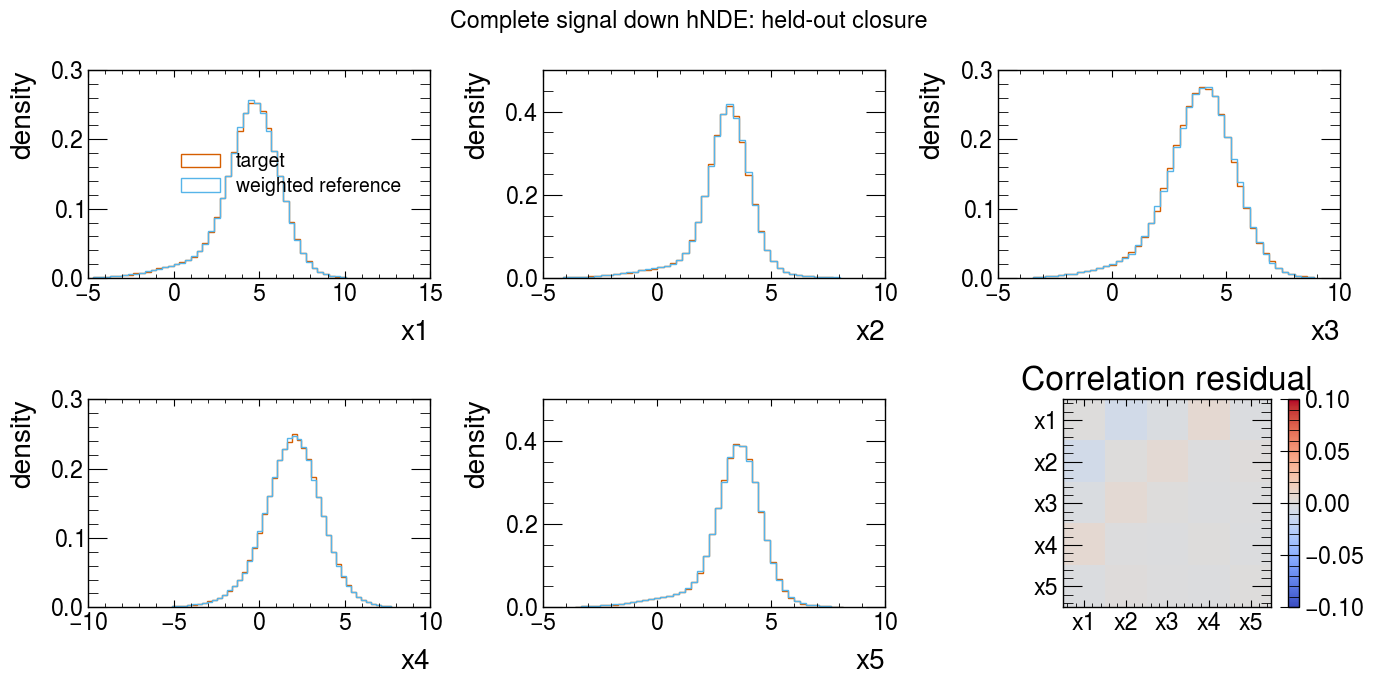

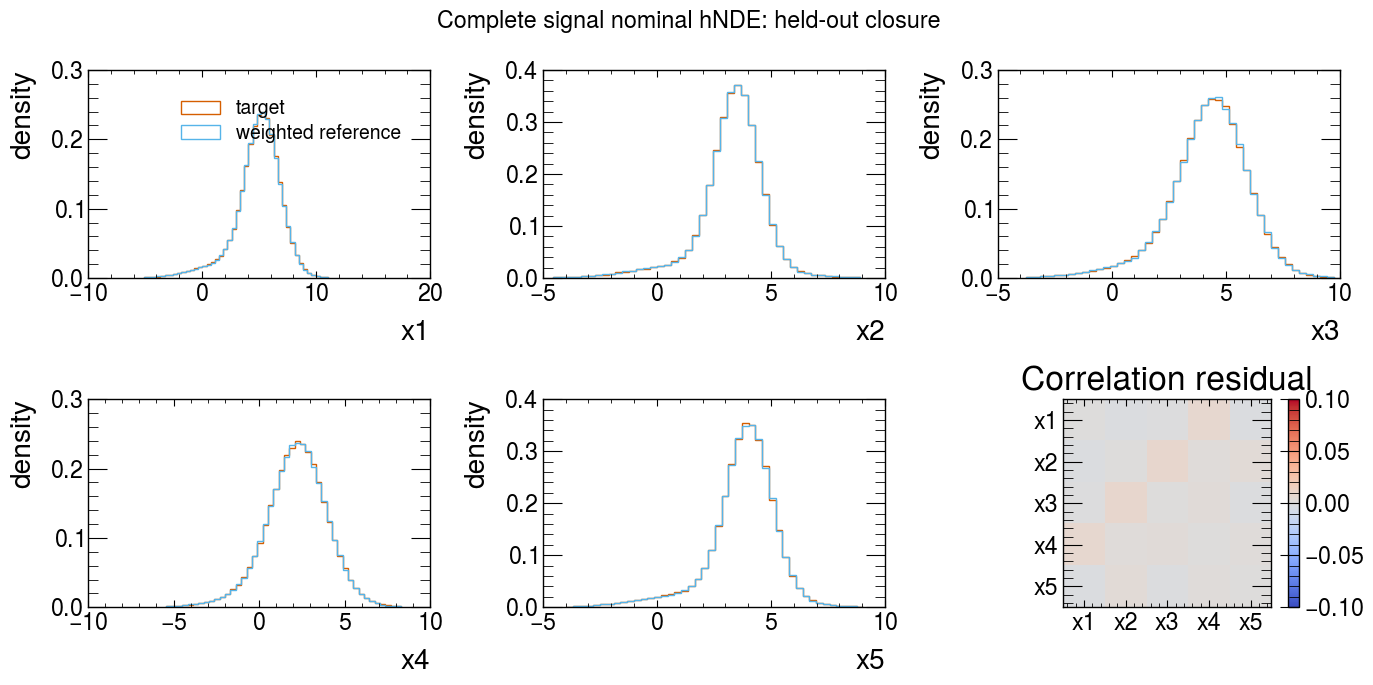

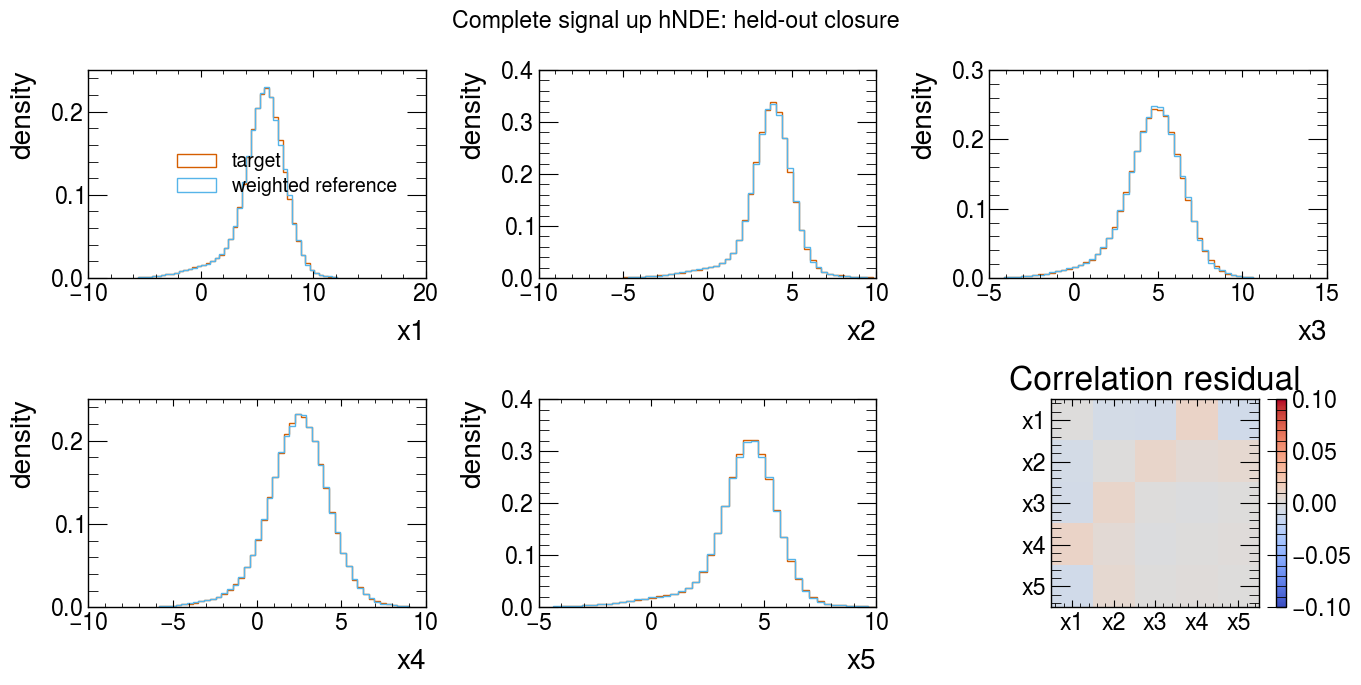

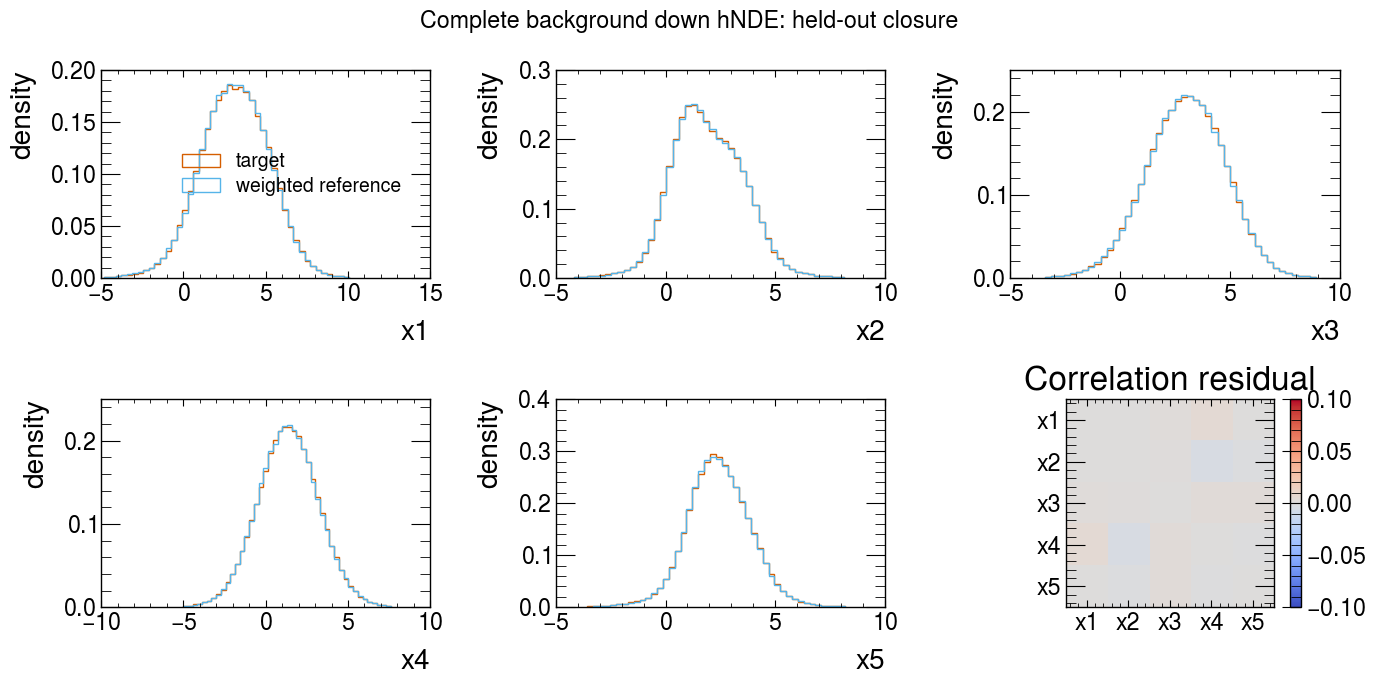

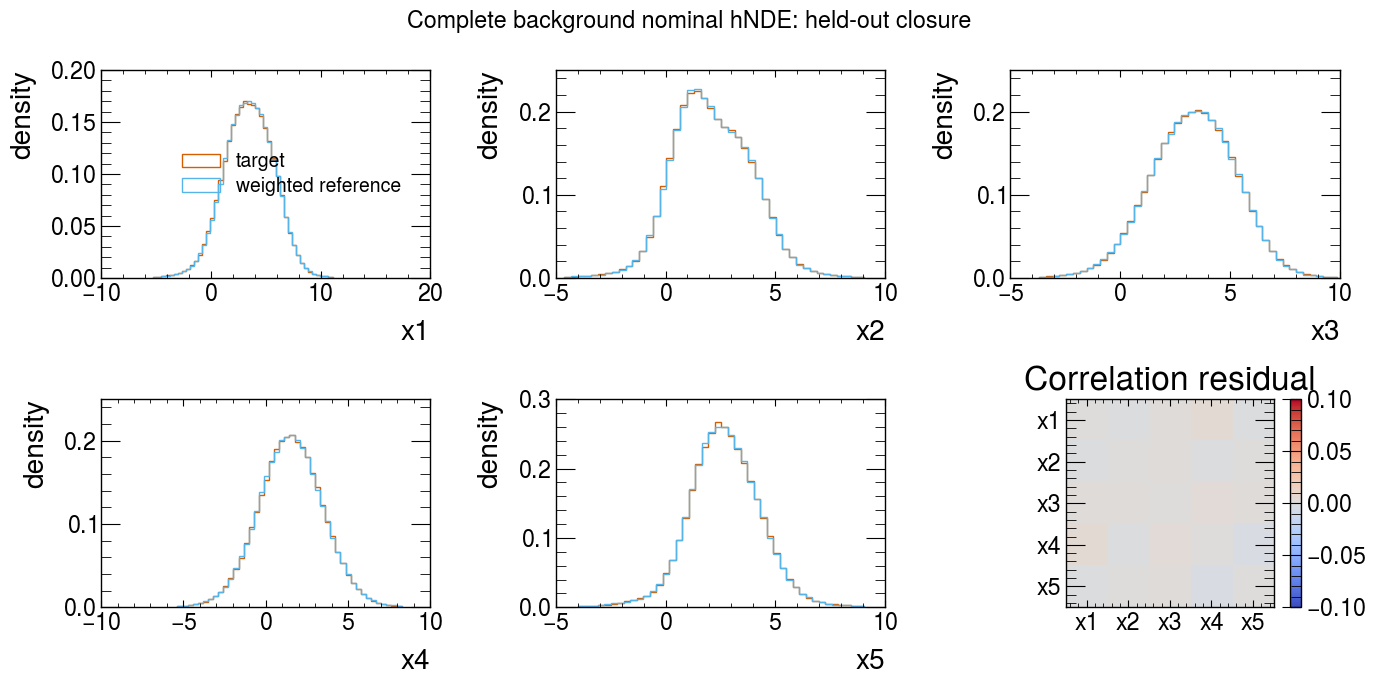

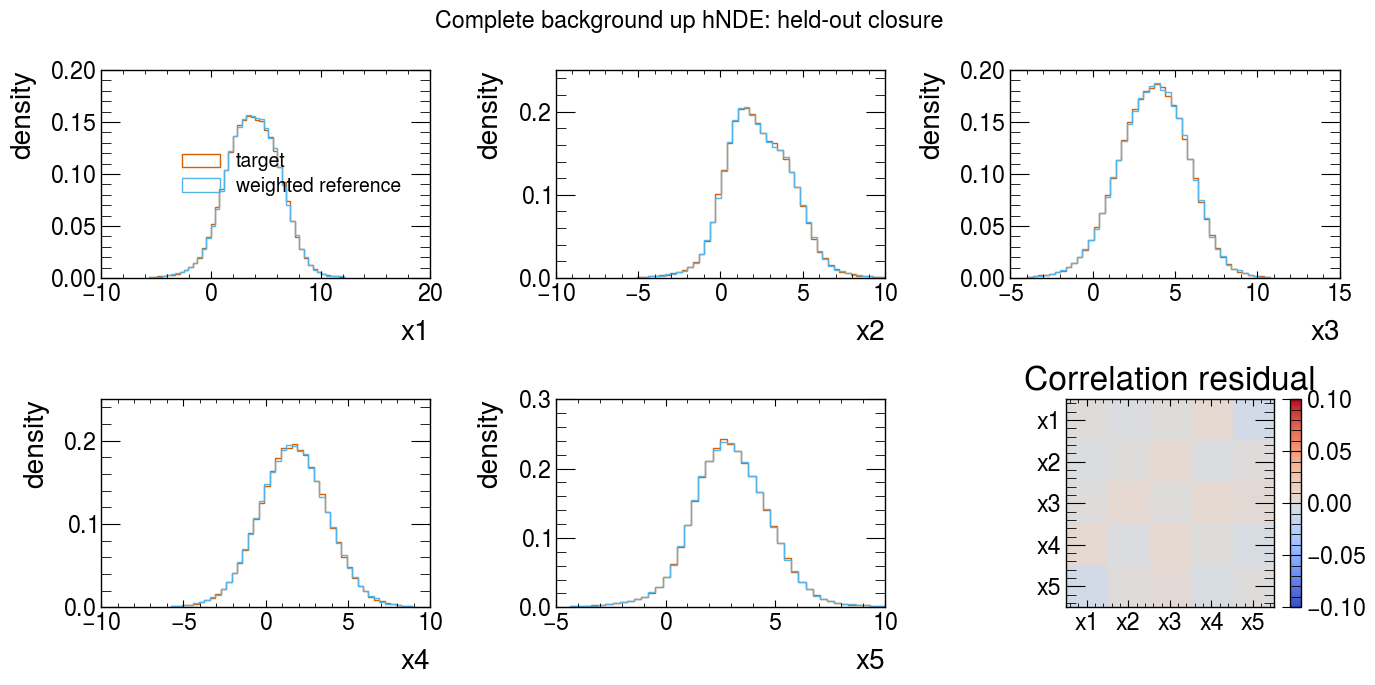

In [9]:
# Independent of training AND of the bank used to estimate Z.
check_x = hybrid.sample_reference(N_DIAGNOSTIC_REFERENCE, SEED + 4)
check_anchors = hybrid.anchors(check_x)
rows = []
for c, process in enumerate(['signal', 'background']):
    for k, direction in enumerate(['down', 'nominal', 'up']):
        r = check_anchors[:, c, k]
        mean, se = r.mean(), r.std(ddof=1) / np.sqrt(len(r))
        rows.append(dict(process=process, anchor=direction, mean=mean,
                         standard_error=se, residual=mean - 1,
                         residual_over_check_SE=(mean - 1) / se,
                         effective_sample_size=r.sum()**2 / np.square(r).sum()))
closure = pd.DataFrame(rows)
closure.to_csv(HYBRID / 'independent_normalization_closure.csv', index=False)
display(closure)

for c, process in enumerate(['signal', 'background']):
    for k, direction in enumerate(['down', 'nominal', 'up']):
        target = read_sample(RUN, process, partition='eval', anchor=direction)
        fig = plot_shape_closure(target, check_x, weights=check_anchors[:, c, k],
                                 title=f'Complete {process} {direction} hNDE: held-out closure')
        fig.savefig(PLOTS / f'complete_{process}_{direction}.png', bbox_inches='tight')
        plt.show()
        del target

The reported standard error is the fresh check-bank uncertainty **conditional on the saved normalization constants**. Their own Monte Carlo uncertainty is additional. A large residual or a low effective sample size calls for a larger integration/check bank and another independent check; with $B=10\,000$, small relative normalization errors can matter in a fit.

The projected plots and correlation residuals are useful diagnostics, not a mathematical guarantee of full five-dimensional agreement. The next notebooks include unbinned inference checks using fresh physical simulator events, which can reveal errors these plots miss.

## 6. Reference-sampled, weighted unbinned Asimov fits

The extended likelihood, after omitting parameter-independent reference-density factors, is

$$\log L_H(\nu,\alpha;D,y)=-\nu S-B
 +\sum_{x\in D}\log[\nu S R_S(x;\alpha)+B R_B(x;\alpha)]
 -\frac{(y-\alpha)^2}{2}.$$

For a model-closure Asimov experiment at $(\mu_A,\alpha_A)$, reuse the normalized integration bank with weights

$$w_j=\frac{\mu_A S R_S(X_j;\alpha_A)+B R_B(X_j;\alpha_A)}{M},
\qquad y_A=\alpha_A.$$

These weights sum to the expected count. They replace the event sum in the NLL; there is no binning. We minimize over both $\nu$ and $\alpha$. `fit` checks the two linear-interpolation branches and the kink at zero.

These are **internal closure tests of the good fitted model**, so the fitted parameters should recover the generating values up to optimizer precision. They do not measure model bias on the physical simulator. In later population-response training, the required auxiliary ensemble is $y\sim\mathrm{Uniform}[-2,2]$, whose expected Gaussian-constraint term has the same parameter dependence as $y=0$. Here $y_A=\alpha_A$ is chosen specifically to test model closure at nonzero anchors.

,mu_A,alpha_A,expected_count,weight_sum,fitted_nu,fitted_alpha,success
0,0.5,-0.5,10050.0,10050.0,0.500000,-0.5,True
1,1.0,0.0,10100.0,10100.0,1.000001,0.0,True
2,1.5,0.5,10150.0,10150.0,1.500000,0.5,True


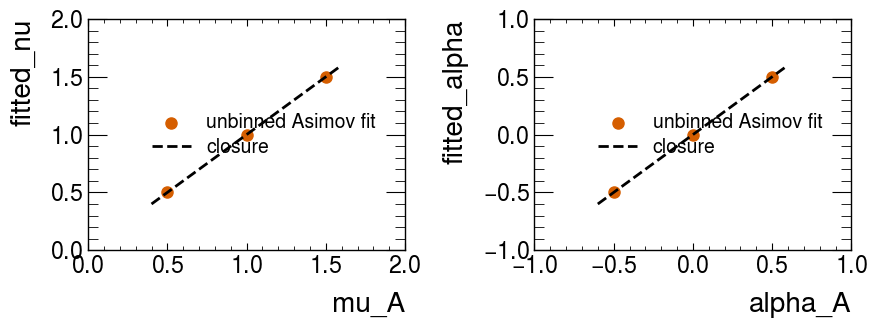

In [10]:
asimov_rows = []
for mu_A, alpha_A in [(0.5, -0.5), (1.0, 0.0), (1.5, 0.5)]:
    weights = asimov_weights(integration_anchors, mu_A, alpha_A, config)
    result = fit(integration_anchors, auxiliary=alpha_A, config=config, weights=weights)
    asimov_rows.append(dict(mu_A=mu_A, alpha_A=alpha_A,
                            expected_count=mu_A * config['signal_yield'] + config['background_yield'],
                            weight_sum=weights.sum(), fitted_nu=result['nu'],
                            fitted_alpha=result['alpha'], success=result['success']))
asimov_results = pd.DataFrame(asimov_rows)
asimov_results.to_csv(HYBRID / 'asimov_closure.csv', index=False)
display(asimov_results)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, truth, fitted in [(axes[0], 'mu_A', 'fitted_nu'),
                          (axes[1], 'alpha_A', 'fitted_alpha')]:
    ax.scatter(asimov_results[truth], asimov_results[fitted], label='unbinned Asimov fit')
    limits = [asimov_results[truth].min() - .1, asimov_results[truth].max() + .1]
    ax.plot(limits, limits, 'k--', label='closure')
    ax.set(xlabel=truth, ylabel=fitted)
    ax.legend()
fig.tight_layout()
fig.savefig(PLOTS / 'asimov_parameter_closure.png')
plt.show()

## What is passed to notebook 03?

`hybrid/` contains the learned reference flow, six ratio estimators (the two nominal estimators are four-member ensembles), six normalization constants, and the reference integration bank. `manifest.json` records their model identity. The next notebook changes one explicit mixture parameter $\epsilon$ while keeping this learned model fixed.

Reference-distribution toys are generated by importance resampling from flow proposals. A shared finite bank makes training practical, but it is an approximation to the continuous hNDE distribution. The helper returns the proposal size and effective sample size; fresh proposal banks and fresh physical toys are used to study this approximation separately. The auxiliary observable in all toys is drawn uniformly from $[-2,2]$, as requested, while the likelihood constraint remains Gaussian.